# Proyek Klasifikasi Gambar: Plants Classification
- **Nama:** M. Sobahus Sururin Ni'am
- **Email:** sobahusn27@gmail.com
- **ID Dicoding:** https://www.dicoding.com/users/sobahusn/

## Import Semua Packages/Library yang Digunakan

In [1]:
# !pip install tensorflow tensorflowjs split-folder

In [2]:
import os
import shutil
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import split_folder

from PIL import Image
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense,
    Dropout, BatchNormalization, Rescaling, GlobalAveragePooling2D
)
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator

## Data Preparation

### Data Loading

In [3]:
# Install Kaggle
!pip install -q kaggle

# Upload kaggle.json
from google.colab import files
files.upload()

# Konfigurasi Kaggle API
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download Dataset
!kaggle datasets download -d marquis03/plants-classification

# Extract Dataset
!unzip -q plants-classification.zip -d dataset

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/marquis03/plants-classification
License(s): apache-2.0
100% 1.34G/1.34G [00:10<00:00, 139MB/s]



### Data Preprocessing

#### Split Dataset

In [4]:
src_folders = ['val', 'test', 'train']
base_path = 'dataset'
combined_path = 'all_data'

os.makedirs(combined_path, exist_ok=True)

for folder in src_folders:
    folder_path = os.path.join(base_path, folder)

    # Skip if the split path (train/val/test) is not a directory
    if not os.path.isdir(folder_path):
        continue

    for class_name in os.listdir(folder_path):
        src_class = os.path.join(folder_path, class_name)
        dst_class = os.path.join(combined_path, class_name)

        # Ensure we are only processing directories (class folders)
        if os.path.isdir(src_class):
            os.makedirs(dst_class, exist_ok=True)

            for file in os.listdir(src_class):
                shutil.copy(
                    os.path.join(src_class, file),
                    os.path.join(dst_class, file)
                )

print("Combine selesai")

Combine selesai


In [5]:
split_folder.ratio(
    input="all_data",
    output="split_dataset",
    seed=42,
    ratio=(.7, .15, .15)
)

print("Split selesai")


Copying (700) of .. train/paddy



  0%|          | 0/700 [00:00<?, ?it/s]


Copying (150) of .. val/paddy



  0%|          | 0/150 [00:00<?, ?it/s]


Copying (150) of .. test/paddy



...


Copying (150) of .. val/guava



  0%|          | 0/150 [00:00<?, ?it/s]


Copying (150) of .. test/guava



  0%|          | 0/150 [00:00<?, ?it/s]

Split selesai


In [6]:
train_dir = 'split_dataset/train'
val_dir = 'split_dataset/val'
test_dir = 'split_dataset/test'

# Konfigurasi transformasi gambar untuk data training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Validasi dan Testing data
test_datagen = ImageDataGenerator(rescale=1./255)

# Menyiapkan aliran data untuk training
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=128,
    class_mode='categorical'
)

# Menyiapkan aliran data untuk validasi (digunakan model untuk evaluasi setiap epoch)
validation_generator = test_datagen.flow_from_directory(
    val_dir,
    target_size=(150, 150),
    batch_size=128,
    class_mode='categorical'
)

# Menyiapkan aliran data untuk pengujian akhir (testing)
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(150, 150),
    batch_size=128,
    class_mode='categorical',
    shuffle=False
)


Found 21000 images belonging to 30 classes.
Found 4500 images belonging to 30 classes.
Found 4500 images belonging to 30 classes.


### Data Augmentation

In [7]:
data_augmentation = tf.keras.Sequential([
  tf.keras.layers.RandomFlip("horizontal_and_vertical"),
  tf.keras.layers.RandomRotation(0.2),
  tf.keras.layers.RandomZoom(0.2),
  tf.keras.layers.RandomContrast(0.2),
])

## Modelling

In [8]:
# Membangun Model Sequential
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(150, 150, 3)),
    MaxPooling2D(2, 2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),

    # Diubah menjadi 30 sesuai jumlah kelas di dataset
    Dense(30, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### Compile Model

In [9]:
# Menggunakan categorical_crossentropy karena ImageDataGenerator menggunakan class_mode='categorical'
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(model.summary())

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 30)             │        15,390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,467,998 (13.23 MB)

 Trainable params: 3,467,998 (13.23 MB)

 Non-trainable params: 0 (0.00 B)

None


## Callback Training

In [10]:
# Mendefinisikan Callbacks
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-5
)

## Training Model

In [11]:
# Training Model
history = model.fit(
    train_generator,
    epochs=50,
    validation_data=validation_generator,
    callbacks=[early_stop, reduce_lr],
)

Epoch 1/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 191s 1s/step - accuracy: 0.1439 - loss: 2.9108 - val_accuracy: 0.2591 - val_loss: 2.4935 - learning_rate: 0.0010
Epoch 2/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 172s 1s/step - accuracy: 0.2568 - loss: 2.4520 - val_accuracy: 0.3533 - val_loss: 2.1379 - learning_rate: 0.0010
Epoch 3/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 172s 1s/step - accuracy: 0.3255 - loss: 2.2364 - val_accuracy: 0.3933 - val_loss: 2.0242 - learning_rate: 0.0010
Epoch 4/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 178s 1s/step - accuracy: 0.3670 - loss: 2.1070 - val_accuracy: 0.4456 - val_loss: 1.8217 - learning_rate: 0.0010
Epoch 5/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 169s 1s/step - accuracy: 0.4046 - loss: 1.9853 - val_accuracy: 0.4767 - val_loss: 1.8002 - learning_rate: 0.0010
Epoch 6/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 170s 1s/step - accuracy: 0.4310 - loss: 1.9078 - val_accuracy: 0.4920 - val_loss: 1.7295 - learning_rate: 0.0010
Epoch 7/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 171s 1s/step - accuracy: 0.4518 - loss: 1.

## Evaluasi dan Visualisasi

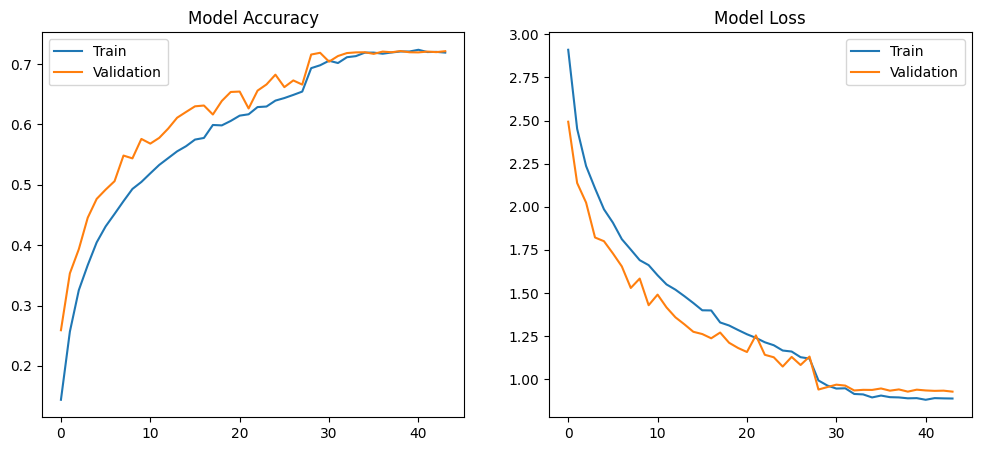

In [12]:
# Visualisasi Accuracy dan Loss
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.legend(["Train","Validation"])

plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Model Loss")
plt.legend(["Train","Validation"])

plt.show()

In [14]:
# Evaluasi Model
test_loss, test_acc = model.evaluate(test_generator)

print("Test Accuracy :", test_acc)
print("Test Loss :", test_loss)

36/36 ━━━━━━━━━━━━━━━━━━━━ 11s 297ms/step - accuracy: 0.7133 - loss: 0.9696
Test Accuracy : 0.7133333086967468
Test Loss : 0.9695849418640137


## Classification Report


In [15]:
# Mendapatkan true labels dari test_generator
y_true = test_generator.classes

# Mendapatkan prediksi dari model
predictions = model.predict(test_generator)
y_pred = np.argmax(predictions, axis=1)

# Mendapatkan nama kelas
class_names = list(test_generator.class_indices.keys())

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

36/36 ━━━━━━━━━━━━━━━━━━━━ 12s 305ms/step
               precision    recall  f1-score   support

     aloevera       0.80      0.73      0.77       150
       banana       0.83      0.73      0.78       150
      bilimbi       0.71      0.71      0.71       150
   cantaloupe       0.33      0.33      0.33       150
      cassava       0.78      0.81      0.79       150
      coconut       0.78      0.86      0.82       150
         corn       0.82      0.80      0.81       150
     cucumber       0.66      0.72      0.69       150
      curcuma       0.79      0.75      0.77       150
     eggplant       0.78      0.87      0.82       150
     galangal       0.77      0.68      0.72       150
       ginger       0.69      0.65      0.67       150
        guava       0.74      0.70      0.72       150
         kale       0.68      0.63      0.65       150
    longbeans       0.74      0.69      0.71       150
        mango       0.62      0.53      0.57       150
        melon       0.

## Konversi Model

### Saved Model

In [16]:
model.export("saved_model")

Saved artifact at 'saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 150, 150, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 30), dtype=tf.float32, name=None)
Captures:
  139822766058064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139822766055376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139822766060560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139822766060752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139822766059984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139822766061328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139822766061520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139822766061136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139822766061712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139822766063440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139822766063056: T

### Konversi ke TensorFlow Lite (TFLite)

In [17]:
converter = tf.lite.TFLiteConverter.from_saved_model("saved_model")
tflite_model = converter.convert()

with open("model.tflite", "wb") as f:
  f.write(tflite_model)

### Konversi ke TensorFlow JS (TFJS)

In [21]:
!tensorflowjs_converter \
  --input_format=tf_saved_model \
  --output_format=tfjs_graph_model \
  saved_model \
  tfjs_model

2026-04-29 23:47:02.134377: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777506422.168184   41282 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777506422.178937   41282 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777506422.203570   41282 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777506422.203607   41282 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777506422.203616   41282 computation_placer.cc:177] computation placer alr

## Inference (Optional)